[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jalonso1979/puremacro/blob/main/curso/notebooks/T09_B_build_your_own_index_es.ipynb)

> **Nota para Google Colab**: la celda siguiente instala `puremacro` y, si hace falta, descarga del repositorio público [jalonso1979/puremacro](https://github.com/jalonso1979/puremacro) sólo la carpeta `curso/notebooks` (auxiliares, datos congelados y modelos). No pide acceso a Google Drive.

In [1]:
# Configuración del entorno: Google Colab, instalación local o Juno (iPad)
import os
import sys
from pathlib import Path

def _safe_probe(p, is_dir=None):
    """¿Existe la ruta? Sin lanzar OSError/PermissionError en el sandbox de Juno."""
    try:
        p = Path(p)
        if is_dir is True:
            return p.is_dir()
        if is_dir is False:
            return p.is_file()
        return p.exists()
    except (OSError, PermissionError, TypeError, ValueError):
        return False

if "google.colab" in sys.modules:
    !pip install -q "puremacro>=4.0.1,<5" openpyxl
    if not _safe_probe(Path.cwd() / "_nbstyle.py", is_dir=False):
        # Clon parcial del repositorio público: sólo curso/notebooks, sin historia
        _repo = Path("/content/puremacro")
        if not _safe_probe(_repo, is_dir=True):
            !git clone -q --depth 1 --filter=blob:none --sparse https://github.com/jalonso1979/puremacro.git {_repo}
        !git -C {_repo} sparse-checkout set curso/notebooks 2>&1 | tail -n 2
        os.chdir(_repo / "curso/notebooks")

# Carpeta con los auxiliares del curso (_nbstyle, _datos) en sys.path, sin salir del sandbox
_candidatos = [Path.cwd(), Path.cwd() / "notebooks", Path.cwd() / "curso/notebooks"]
try:
    _candidatos.insert(0, Path(__file__).resolve().parent)  # Juno define __file__
except (NameError, OSError):
    pass
for _c in _candidatos:
    if _safe_probe(_c / "_nbstyle.py", is_dir=False):
        if str(_c) not in sys.path:
            sys.path.insert(0, str(_c))
        break

# Gráficas en línea y estilo del curso
%matplotlib inline
try:
    import _nbstyle
    _nbstyle.apply_style()
except ImportError:
    pass

# Construcción de Índices Macroeconómicos y de Incertidumbre: De Señales Micro a Modelos de Factores Dinámicos

Los índices de incertidumbre macroeconómica y de condiciones financieras a menudo parecen infraestructuras propietarias y opacas, reservadas a terminales comerciales o servicios de suscripción costosos. En realidad, los índices publicados descansan sobre principios econométricos rigurosos y transparentes diseñados para sintetizar información de alta dimensión en indicadores escalares del estado de la economía.

La metodología contemporánea de construcción de índices se articula en torno a cuatro enfoques fundamentales:
1. **Co-ocurrencia Semántica en Texto (Incertidumbre Narrativa)**: Formalizada por **Baker, Bloom y Davis (BBD 2016)** para el Índice de Incertidumbre de Política Económica (EPU). Un artículo o documento se clasifica como indicador de incertidumbre cuando combina simultáneamente tres categorías léxicas: economía, política gubernamental e incertidumbre.
2. **Volatilidad Condicional de Pronóstico (Incertidumbre Macroeconómica)**: Desarrollada por **Jurado, Ludvigson y Ng (JLN 2015)**. La incertidumbre macroeconómica no equivale a la volatilidad no condicional observada, sino a la varianza *impredecible* de las innovaciones futuras. Tras proyectar un panel macroeconómico sobre factores comunes, se modela la volatilidad condicional de los errores de predicción mediante estimadores GARCH.
3. **Compresión por Componentes Principales (Índice de Condiciones Financieras)**: Empleada por **Adrian, Boyarchenko y Giannone (2019)** en la literatura de Crecimiento en Riesgo (*Growth-at-Risk*) y en el Índice Nacional de Condiciones Financieras (NFCI) de la Fed de Chicago. Un conjunto de diferenciales crediticios, primas por plazo y volatilidad bursátil se comprime en el primer factor latente, normalizando el signo para que valores positivos indiquen restricción financiera.
4. **Modelos de Factores Dinámicos (DFM) y Predicción Inmediata (Nowcasting)**: Introducidos por **Stock y Watson (1989, 2002, 2016)** y formalizados para tiempo real por **Giannone, Reichlin y Small (2008)**. Un panel de indicadores coincidentes mensuales comparte un factor común latente $F_t$ que captura la trayectoria del ciclo económico, permitiendo rastrear recesiones oficiales de la NBER y predecir el PIB real trimestral con anticipación.

En este cuaderno desarrollamos cada uno de estos cuatro núcleos metodológicos con `puremacro` y culminamos con un experimento capstone empírico: la estimación de un **Índice de Factores Dinámicos de Stock-Watson** utilizando series mensuales genuinas de la Reserva Federal.

In [2]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.narrative.indices import epu
from puremacro.factor import pca_factors
from puremacro.garch import garch11_fit
from puremacro.gar import fci
from puremacro.volatility.sigma import SigmaObject
from puremacro.regress import ols

# Guarda de pureza: ninguno de estos módulos pesados o de pago debe haberse colado.
_bad = [m for m in ("bs4", "requests", "anthropic", "sentence_transformers",
                    "statsmodels", "linearmodels", "arch", "numba") if m in sys.modules]
assert _bad == [], f"Fuga inesperada de módulos: {_bad}"

RNG = np.random.default_rng(13)

## Receta 1 — Análisis de Texto: El Núcleo EPU de Baker-Bloom-Davis (2016)

**Núcleo: Co-ocurrencia semántica de tres grupos.** Un documento califica como portador de incertidumbre cuando satisface la intersección booleana:
$$\text{Documento} \in \{\text{Economía}\} \cap \{\text{Política}\} \cap \{\text{Incertidumbre}\}$$
La frecuencia mensual de documentos coincidentes en el corpus de noticias se estandariza y normaliza (`normalize="bbd_100"`, fijando media 100 y desviación estándar 50 en el periodo base). En la siguiente simulación, inyectamos una perturbación de incertidumbre en 2020 y certificamos que el algoritmo recupera con nitidez la señal.

In [3]:
NEUTRAL = ["local sports results were mixed", "the weather stayed mild",
           "a new museum opened downtown", "rail service ran on schedule"]
ECON = ["the economy expanded", "gdp and output", "economic growth"]
EPU_HIGH = [   # ← cambia por tu propio corpus; cada frase debe unir economía ∧ política ∧ incertidumbre
    "economic policy uncertainty is high amid uncertain fiscal regulation",
    "uncertain trade policy is weighing on the economy",
    "regulatory uncertainty clouds the economic policy outlook",
]
HIGH_START, HIGH_END = pd.Timestamp("2020-01-01"), pd.Timestamp("2020-12-31")

records = []
for month in pd.date_range("2018-01-01", "2022-12-01", freq="MS"):
    for _ in range(4):
        d = pd.Timestamp(month + pd.Timedelta(days=int(RNG.integers(0, 27))))
        in_w = HIGH_START <= d <= HIGH_END
        base = NEUTRAL[int(RNG.integers(0, len(NEUTRAL)))] + ". " + ECON[int(RNG.integers(0, len(ECON)))]
        sig = EPU_HIGH[int(RNG.integers(0, len(EPU_HIGH)))] if RNG.random() < (0.75 if in_w else 0.08) else ""
        records.append((d, (base + ". " + sig).strip(), "syn://news", {"language": "en"}))

epu_s = epu(records, country="SYN", language="en", normalize="bbd_100").series.dropna()
_w = (epu_s.index >= HIGH_START) & (epu_s.index <= HIGH_END)
epu_gap = epu_s[_w].mean() - epu_s[~_w].mean()
print(f"[1] EPU de texto: brecha dentro menos fuera de la ventana = {epu_gap:.1f} puntos bbd")
assert epu_gap > 25

[1] EPU de texto: brecha dentro menos fuera de la ventana = 118.9 puntos bbd


## Receta 2 — Paneles Macroeconómicos: El Núcleo de Incertidumbre de Jurado-Ludvigson-Ng (2015)

**Núcleo: Factores comunes + volatilidad condicional del error de pronóstico.** La incertidumbre macroeconómica refleja la variabilidad impredecible de la actividad económica futura. La metodología JLN se ejecuta en cuatro fases:
1. Extraer factores latentes comunes $F_t$ a partir de un panel macroeconómico mediante componentes principales con `pca_factors`.
2. Calcular los residuos de predicción a un periodo hacia adelante $e_{j, t+1} = X_{j, t+1} - \mathbb{E}_t[X_{j, t+1} \mid F_t]$ para cada serie $j$.
3. Estimar la trayectoria de volatilidad condicional $\sigma_{j, t+1}^2$ de cada residuo mediante un proceso GARCH(1,1) con `garch11_fit`.
4. Agregar las trayectorias de incertidumbre individual en un índice macroeconómico agregado $U_t = \frac{1}{N} \sum_{j=1}^N \sigma_{j, t}$.

In [4]:
T, n = 240, 8
t = np.arange(T)
vol_hi, win = 3.5, 30                                   # ← ventana inyectada de alta volatilidad
sig_t = np.where((t >= T // 2) & (t < T // 2 + win), vol_hi, 1.0)
f_true = np.zeros(T)
for i in range(1, T):
    f_true[i] = 0.5 * f_true[i - 1] + sig_t[i] * RNG.standard_normal()
loadings = RNG.uniform(0.3, 1.0, size=n)
X = np.outer(f_true, loadings) + 0.5 * RNG.standard_normal((T, n))     # panel macro (T, n)

F = pca_factors(X, k=1)["factors"]                      # factor común (T, 1)
F_lag = np.vstack([np.zeros((1, 1)), F[:-1]])           # F_{t-1}
U = np.zeros(T)
for j in range(n):
    Z = np.column_stack([np.ones(T), F_lag[:, 0]])      # pronóstico con una constante + el factor rezagado
    res = ols(X[:, j], Z, cov_type="HAC")
    resid = res.resid                                   # error de pronóstico a un paso
    U += np.asarray(garch11_fit(resid).sigma)           # su trayectoria de volatilidad condicional
U = pd.Series(U / n, index=pd.RangeIndex(T))            # promedio entre las series

mid = U[T // 2:T // 2 + win].mean()
rest = pd.concat([U[:T // 2], U[T // 2 + win:]]).mean()
print(f"[2] incertidumbre macro al estilo JLN: media en la ventana {mid:.2f} vs resto {rest:.2f} (razón {mid/rest:.2f})")
assert mid > 1.2 * rest

[2] incertidumbre macro al estilo JLN: media en la ventana 1.68 vs resto 0.91 (razón 1.86)


## Receta 3 — Indicadores Financieros: El Núcleo del Índice de Condiciones Financieras (FCI)

**Núcleo: Primer componente principal con normalización de signo hacia restricción.** Las condiciones financieras sintetizan el costo y la disponibilidad del financiamiento en los mercados de capital. La rutina `gar.fci` estandariza las variables financieras (diferenciales de crédito, primas por plazo, volatilidad y valoraciones accionarias), extrae el primer componente principal y orienta su signo para que los indicadores de restricción (`tightening_columns`) carguen positivamente en términos netos. Valores positivos del FCI denotan condiciones crediticias restrictivas vinculadas a riesgos a la baja en el PIB (Adrian et al. 2019).

In [5]:
stress = np.zeros(T)
for i in range(1, T):
    stress[i] = 0.85 * stress[i - 1] + RNG.standard_normal()        # factor latente de estrés financiero
fin = pd.DataFrame({
    "credit_spread": 0.8 * stress + 0.4 * RNG.standard_normal(T),   # más alto = más restrictivo
    "equity_vol":    0.7 * stress + 0.5 * RNG.standard_normal(T),   # más alto = más restrictivo
    "term_spread":  -0.6 * stress + 0.5 * RNG.standard_normal(T),   # más alto = más laxo
    "equity_price": -0.7 * stress + 0.5 * RNG.standard_normal(T),   # más alto = más laxo
}, index=pd.RangeIndex(T))

out = fci(fin, tightening_columns=["credit_spread", "equity_vol"])  # ← nombra tus columnas "restrictivas cuando suben"
fci_idx = pd.Series(out["index"], index=fin.index)
corr_stress = float(np.corrcoef(fci_idx, stress)[0, 1])
print(f"[3] FCI: varianza explicada por el CP1 = {out['var_explained']:.2f}; corr(FCI, estrés latente) = {corr_stress:+.2f}")
assert out["var_explained"] > 0.4 and corr_stress > 0.7

[3] FCI: varianza explicada por el CP1 = 0.89; corr(FCI, estrés latente) = +0.98


## Receta 4 — Secciones Transversales de Volatilidad: La Prima de Comovimiento

**Núcleo: Descomposición cuadrática de la varianza agregada.** El riesgo macroeconómico agregado depende no solo de las volatilidades sectoriales individuales, sino de su correlación cruzada sistemática (Foerster, Sarte y Watson 2011). Sea el crecimiento del producto agregado $g_t = w' y_t$, con matriz de covarianzas $\Sigma = \mathrm{diag}(\sigma) R \mathrm{diag}(\sigma)$. La varianza agregada es $\mathrm{Var}(g_t) = w' \Sigma w$.

Empleando `puremacro.volatility.sigma.SigmaObject`, aislamos la **prima de covarianza**:
$$\text{Prima} = \frac{w' \Sigma w - \sum_i w_i^2 \sigma_i^2}{\sum_i w_i^2 \sigma_i^2}$$
la cual cuantifica el incremento porcentual en la volatilidad macroeconómica agregada generado por el comovimiento intersectorial.

In [6]:
labels = ["manuf", "services", "construction", "retail", "energy"]
sig = np.array([2.0, 1.2, 3.0, 1.5, 4.0])               # ← volatilidades por sector
rho = 0.6                                               # ← correlación común entre pares
R = (1 - rho) * np.eye(len(sig)) + rho * np.ones((len(sig), len(sig)))
w = np.full(len(sig), 1 / len(sig))                     # ← ponderaciones (iguales aquí)

S = SigmaObject(sig, R, labels)
var_with, var_without = S.var(w), S.var_no_cov(w)       # varianza agregada con y sin covarianzas
premium = (var_with - var_without) / var_without        # la prima de covarianza
print(f"[4] comovimiento: correlación media = {S.mean_corr():.2f}; prima de covarianza = {premium:.1%}")
assert premium > 0


[4] comovimiento: correlación media = 0.60; prima de covarianza = 191.3%


### Síntesis Comparativa: Cuatro Núcleos Metodológicos de Índices

La figura en cuatro paneles contrasta las propiedades dinámicas y transversales de las cuatro metodologías de construcción de índices. Cada enfoque responde a una modalidad de datos específica —texto no estructurado, paneles de series temporales, precios de activos financieros y datos sectoriales desglosados— mediante operaciones matemáticas transparentes y reproducibles. Los tres primeros paneles muestran las series estandarizadas (media cero y desviación estándar unitaria) para hacerlas comparables entre sí; el cuarto reporta las contribuciones sectoriales $w_i^2 \sigma_i^2$ a la varianza agregada.

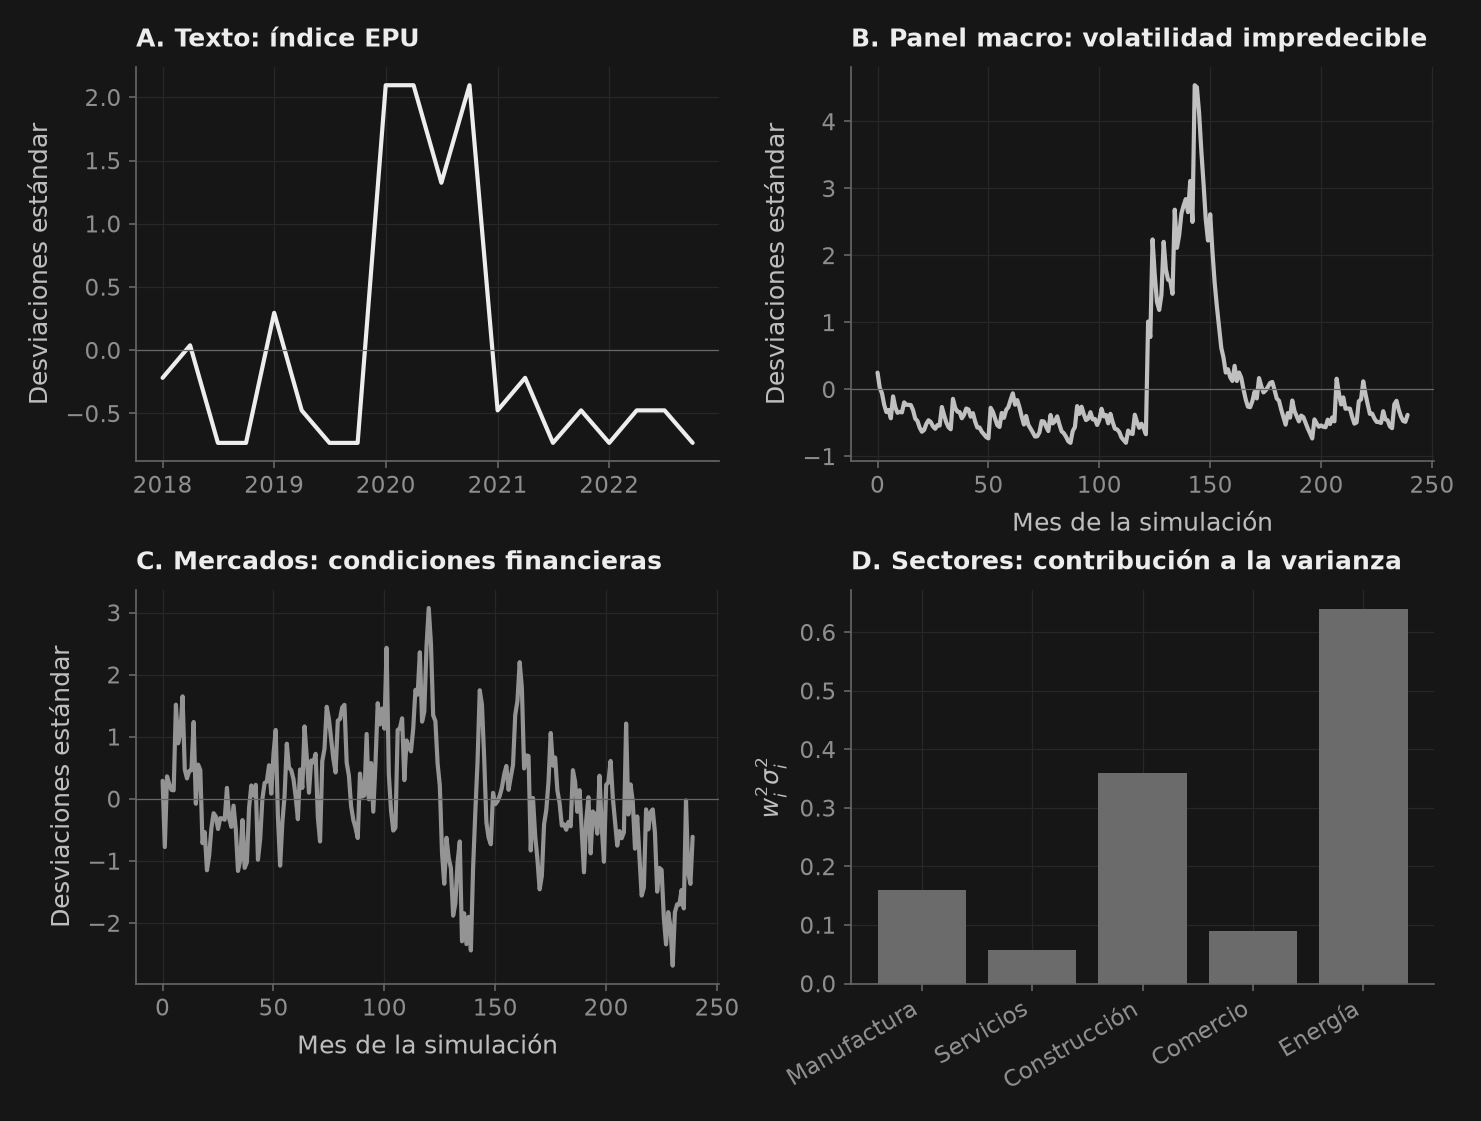

In [7]:
cols = _nbstyle.palette(4)
def _z(s):
    s = np.asarray(s, dtype=float)
    return (s - np.nanmean(s)) / np.nanstd(s)

sector_labels = ["Manufactura", "Servicios", "Construcción", "Comercio", "Energía"]

fig, axes = _nbstyle.figura(2, 2)
axes[0, 0].plot(epu_s.index, _z(epu_s.values), color=cols[0], ls="-")
axes[0, 0].set_title("A. Texto: índice EPU")
axes[0, 1].plot(U.index, _z(U.values), color=cols[1], ls="-")
axes[0, 1].set_title("B. Panel macro: volatilidad impredecible")
axes[1, 0].plot(fci_idx.index, _z(fci_idx.values), color=cols[2], ls="-")
axes[1, 0].set_title("C. Mercados: condiciones financieras")
axes[1, 1].bar(range(len(labels)), S.diag_contrib(w), color=cols[3])
axes[1, 1].set_xticks(range(len(labels)))
axes[1, 1].set_xticklabels(sector_labels, rotation=30, ha="right")
axes[1, 1].set_title("D. Sectores: contribución a la varianza")
axes[1, 1].set_ylabel(r"$w_i^2\sigma_i^2$")
for ax in axes.flat[:3]:
    ax.axhline(0, color=_nbstyle.SPINE, linewidth=0.6)
    ax.set_ylabel("Desviaciones estándar")
for ax in (axes[0, 1], axes[1, 0]):
    ax.set_xlabel("Mes de la simulación")
plt.show()


## Taxonomía Metodológica de Índices

| Modalidad de Datos | Núcleo Teórico | Objetivo Econométrico | Implementación en puremacro |
|---|---|---|---|
| **Corpus de Texto (No Estructurado)** | Co-ocurrencia semántica | Incertidumbre de Política Económica (BBD 2016) | `puremacro.narrative.indices.epu` |
| **Panel Macroeconómico** | Proyección factorial + GARCH | Incertidumbre Macroeconómica Impredecible (JLN 2015) | `factor.pca_factors` → `garch.garch11_fit` |
| **Indicadores Financieros** | Componente principal + normalización | Índice de Condiciones Financieras (Adrian et al. 2019) | `puremacro.gar.fci` |
| **Volatilidades Sectoriales** | Forma cuadrática $\sigma \cdot R$ | Prima de Comovimiento Agregado (Foerster et al. 2011) | `puremacro.volatility.sigma.SigmaObject` |
| **Panel Mensual de Indicadores Coincidentes** | Modelo de Factores Dinámicos ($X_t = \Lambda F_t + e_t$) | Seguimiento de Recesiones y Nowcasting (Stock-Watson) | `puremacro.factor.pca_factors` |

## Experimento Capstone: Índice de Predicción Inmediata (Nowcasting) de Factores Dinámicos de Stock-Watson

### Contexto Económico y Motivación
Las cifras oficiales del Producto Interno Bruto (PIB) real se publican con rezagos sustanciales de información (frecuentemente entre 30 y 60 días tras el cierre del trimestre de referencia). En tiempo real, los bancos centrales, las instituciones financieras y los encargados de la política macroeconómica deben monitorear indicadores mensuales de alta frecuencia para diagnosticar el estado del ciclo económico antes de la publicación de las cuentas nacionales oficiales.

La literatura seminal sobre **Modelos de Factores Dinámicos (DFM)** desarrollada por **Stock y Watson (1989, 2002, 2016)** y formalizada por **Giannone, Reichlin y Small (2008)** establece que las series macroeconómicas comparten un componente común no observable impulsado por el ciclo de negocios agregado:
$$X_t = \Lambda F_t + e_t$$
donde $X_t$ es un panel estandarizado de indicadores coincidentes mensuales, $\Lambda$ es la matriz de cargas factoriales, $F_t$ representa el factor dinámico latente de actividad económica real, y $e_t$ son perturbaciones idiosincrásicas sectoriales.

En este experimento capstone, extraemos el factor latente común $F_t$ a partir de cinco series mensuales genuinas de la Reserva Federal disponibles localmente en `data_curso/`:
1. Índice de Producción Industrial (`INDPRO.csv`)
2. Nómina No Agrícola del Sector Privado (`USPRIV.csv`)
3. Horas Promedio Semanales en Manufactura (`AWHI.csv`)
4. Utilización de la Capacidad Instalada (`TCU.csv`)
5. Tasa de Desempleo Civil (`UNRATE.csv`)

### Tareas Guiadas del Estudiante
1. Cargar las cinco series coincidentes mensuales junto con el indicador de recesiones de la NBER (`USREC.csv`) y el PIB real trimestral (`GDPC1.csv`).
2. Transformar las series a innovaciones estacionarias (crecimiento porcentual mensual para producción y empleo; primeras diferencias para horas, capacidad instalada y desempleo invertido).
3. Estandarizar el panel y extraer el primer factor común $F_t$ mediante `puremacro.factor.pca_factors(X, k=1)`. Normalizar su orientación respecto al crecimiento industrial.
4. Evaluar el comportamiento del factor en periodos de tensión histórica: verificar las caídas pronunciadas en la Gran Recesión de 2008 ($< -2.0\,\text{std}$) y el confinamiento de abril de 2020 ($< -10.0\,\text{std}$).
5. Agregar el factor a frecuencia trimestral y evaluar su capacidad de predicción contemporánea (*nowcasting*) frente al crecimiento del PIB real oficial ($r > 0.70$).

Varianza Explicada por el Primer Factor (Stock-Watson): 87.0%
Mínimo en la Gran Recesión Financiera (2008 GFC):      -2.21 d.e.
Colapso por Confinamiento COVID (abril 2020):           -17.29 d.e.
Correlación Predictiva Trimestral con el PIB Real:      0.84


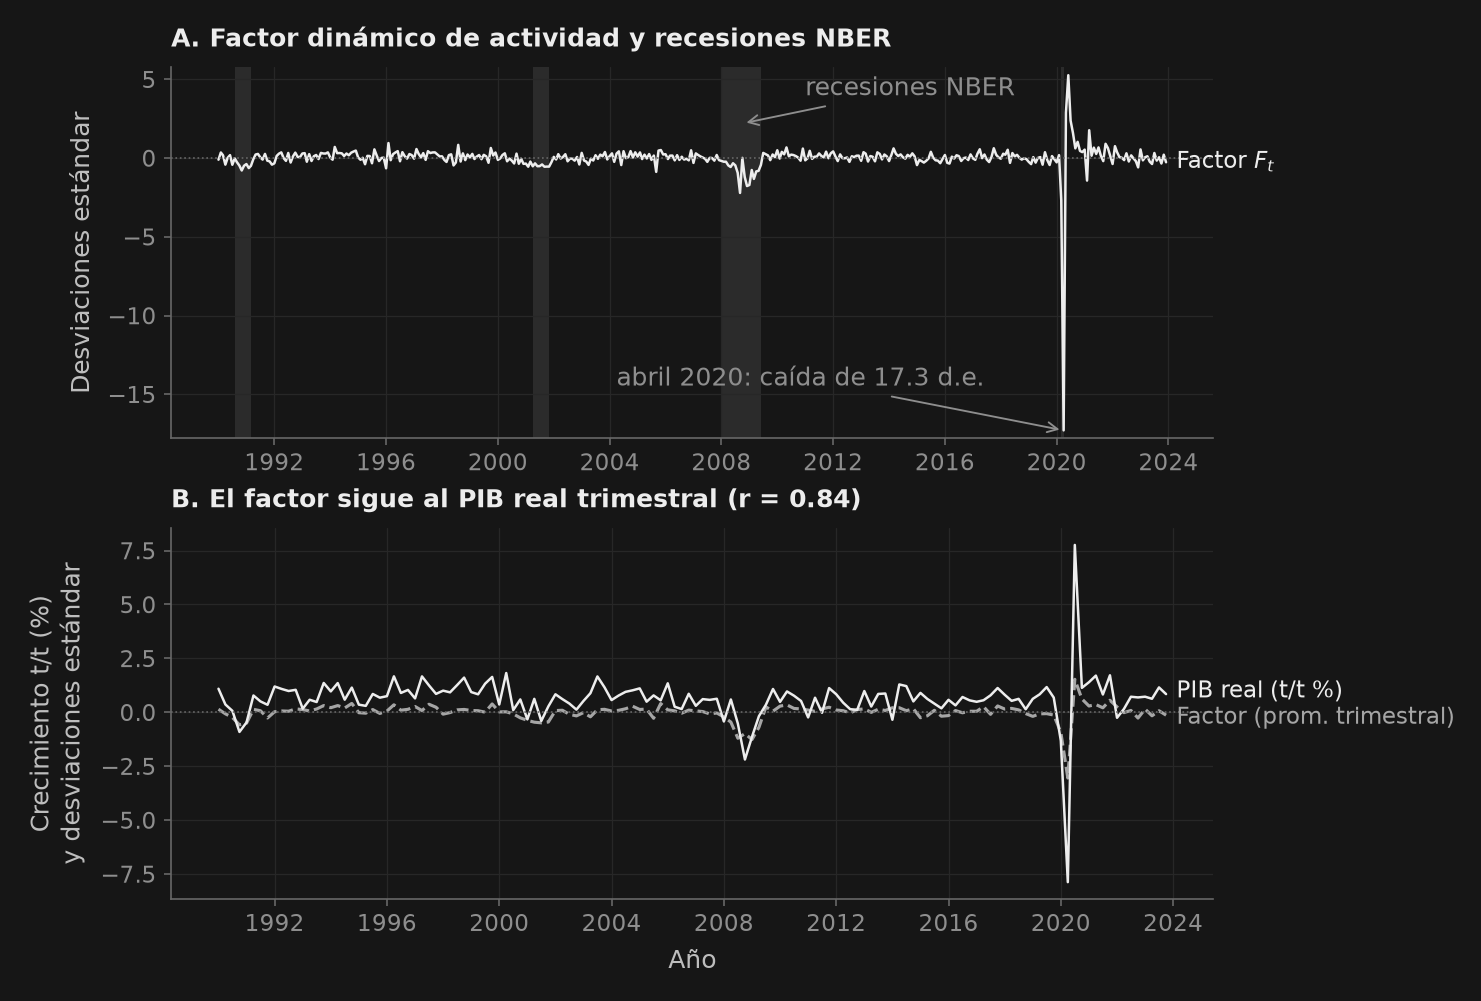

In [8]:
data_dir = Path("data_curso") if Path("data_curso").exists() else Path("notebooks/data_curso")

# 1. Cargar indicadores macroeconómicos empíricos genuinos de la Reserva Federal
indpro = pd.read_csv(data_dir / "INDPRO.csv", parse_dates=["observation_date"]).set_index("observation_date")["INDPRO"]
uspriv = pd.read_csv(data_dir / "USPRIV.csv", parse_dates=["observation_date"]).set_index("observation_date")["USPRIV"]
awhi = pd.read_csv(data_dir / "AWHI.csv", parse_dates=["observation_date"]).set_index("observation_date")["AWHI"]
tcu = pd.read_csv(data_dir / "TCU.csv", parse_dates=["observation_date"]).set_index("observation_date")["TCU"]
unrate = pd.read_csv(data_dir / "UNRATE.csv", parse_dates=["observation_date"]).set_index("observation_date")["UNRATE"]
usrec = pd.read_csv(data_dir / "USREC.csv", parse_dates=["observation_date"]).set_index("observation_date")["USREC"]
gdp = pd.read_csv(data_dir / "GDPC1.csv", parse_dates=["observation_date"]).set_index("observation_date")["GDPC1"]

# 2. Transformar en innovaciones mensuales estacionarias
df_macro = pd.DataFrame()
df_macro["indpro_g"] = indpro.pct_change(1) * 100.0
df_macro["uspriv_g"] = uspriv.pct_change(1) * 100.0
df_macro["awhi_d"] = awhi.diff(1)
df_macro["tcu_d"] = tcu.diff(1)
df_macro["unrate_d"] = -unrate.diff(1)  # Invertido para que expansión sea positiva

df_macro = df_macro.dropna().loc["1990-01-01":"2023-12-01"]

# 3. Extraer el factor dinámico común mediante puremacro
res = pca_factors(df_macro.to_numpy(), k=1)
F = res["factors"]
var_share = float(res["variance_share"][0])

# Normalización de signo: alinear orientación con el crecimiento de producción industrial
if np.corrcoef(F[:, 0], df_macro["indpro_g"])[0, 1] < 0:
    F = -F
df_macro["factor"] = F[:, 0]
df_macro["usrec"] = usrec.reindex(df_macro.index).fillna(0)

# 4. Pruebas de estrés a lo largo de recesiones históricas
gfc_min = float(df_macro.loc["2008-01-01":"2009-12-01", "factor"].min())
covid_min = float(df_macro.loc["2020-01-01":"2020-06-01", "factor"].min())

# 5. Correlación de predicción inmediata (nowcasting) trimestral con el PIB Real
q_factor = df_macro["factor"].resample("QS-OCT").mean()
gdp_g = (gdp.pct_change(1) * 100.0).dropna()
comp = pd.DataFrame({"factor_q": q_factor, "gdp_g": gdp_g}).dropna().loc["1990-01-01":"2023-12-01"]
corr_gdp = float(np.corrcoef(comp["factor_q"], comp["gdp_g"])[0, 1])

print(f"Varianza Explicada por el Primer Factor (Stock-Watson): {var_share * 100:.1f}%")
print(f"Mínimo en la Gran Recesión Financiera (2008 GFC):      {gfc_min:.2f} d.e.")
print(f"Colapso por Confinamiento COVID (abril 2020):           {covid_min:.2f} d.e.")
print(f"Correlación Predictiva Trimestral con el PIB Real:      {corr_gdp:.2f}")

# 6. Visualización del factor dinámico y las recesiones históricas.
#    Dos tiras temporales largas apiladas: TAMANO no tiene una clave 2x1 a todo lo ancho.
fig, (ax1, ax2) = _nbstyle.figura(2, 1, figsize=(9.6, 6.4))

# Panel A: factor dinámico mensual y recesiones NBER
y_min = df_macro["factor"].min() - 0.5
y_max = df_macro["factor"].max() + 0.5
ax1.fill_between(df_macro.index, y_min, y_max, where=df_macro["usrec"] == 1,
                 color=_nbstyle.RECESION, lw=0, zorder=0)
ax1.plot(df_macro.index, df_macro["factor"], color=_nbstyle.TINTA, lw=1.2, ls="-",
         label="Factor $F_t$")
ax1.axhline(0, color=_nbstyle.SPINE, lw=0.8, ls=":")
ax1.set_ylim(y_min, y_max)
ax1.set_ylabel("Desviaciones estándar")
ax1.set_title("A. Factor dinámico de actividad y recesiones NBER")
ax1.annotate("recesiones NBER", xy=(pd.Timestamp("2008-10-01"), 2.2),
             xytext=(pd.Timestamp("2011-01-01"), 4.4), ha="left", va="center",
             color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)
ax1.annotate(f"abril 2020: caída de {abs(covid_min):.1f} d.e.", xy=(pd.Timestamp("2020-04-01"), covid_min),
             xytext=(pd.Timestamp("2017-06-01"), -14.0), ha="right", va="center",
             color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)

# Panel B: factor trimestral frente al crecimiento oficial del PIB real
ax2.plot(comp.index, comp["factor_q"], color=_nbstyle.S2["color"], lw=1.5, ls="--",
         label="Factor (prom. trimestral)")
ax2.plot(comp.index, comp["gdp_g"], color=_nbstyle.TINTA, lw=1.2, ls="-",
         label="PIB real (t/t %)")
ax2.axhline(0, color=_nbstyle.SPINE, lw=0.8, ls=":")
ax2.set_ylabel("Crecimiento t/t (%)\ny desviaciones estándar")
ax2.set_xlabel("Año")
ax2.set_title(f"B. El factor sigue al PIB real trimestral (r = {corr_gdp:.2f})")

_nbstyle.etiquetar(ax1, donde="fin")
_nbstyle.etiquetar(ax2, donde="fin")
plt.show()

# 7. Aserciones de Verificación Objetiva
assert var_share > 0.50, f"Se esperaba que el factor explicara >50% de la varianza, se obtuvo {var_share*100:.1f}%"
assert gfc_min < -2.0, f"Se esperaba caída GFC 2008 < -2.0 d.e., se obtuvo {gfc_min:.2f}"
assert covid_min < -10.0, f"Se esperaba desplome COVID 2020 < -10.0 d.e., se obtuvo {covid_min:.2f}"
assert corr_gdp > 0.70, f"Se esperaba correlación con PIB trimestral > 0.70, se obtuvo {corr_gdp:.2f}"
